# **Import Modules**

In [31]:
!pip install optuna

In [92]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

import optuna

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score
from xgboost import XGBClassifier

# **Load The Dataset**

In [4]:
df = pd.read_csv('mushrooms.csv')

# **Data Understanding**

In [9]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [13]:
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [15]:
df.duplicated().sum()

0

In [115]:
df['class'].value_counts()

class
0    4208
1    3916
Name: count, dtype: int64

# **EDA**

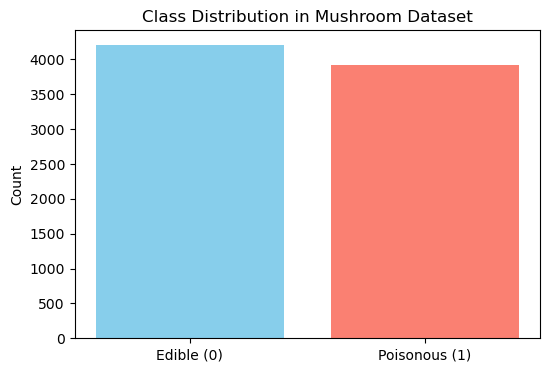

In [123]:
import matplotlib.pyplot as plt

# Count values
counts = df['class'].value_counts()

# Plot
plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values, color=['skyblue', 'salmon'])
plt.xticks([0,1], ['Edible (0)', 'Poisonous (1)'])
plt.ylabel('Count')
plt.title('Class Distribution in Mushroom Dataset')
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_6908\3346253529.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette=['skyblue','salmon'])


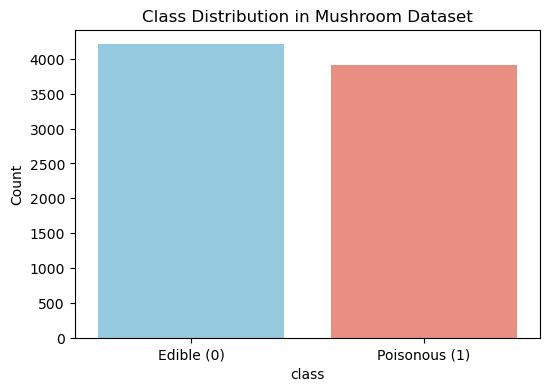

In [119]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df, palette=['skyblue','salmon'])
plt.xticks([0,1], ['Edible (0)', 'Poisonous (1)'])
plt.ylabel('Count')
plt.title('Class Distribution in Mushroom Dataset')
plt.show()


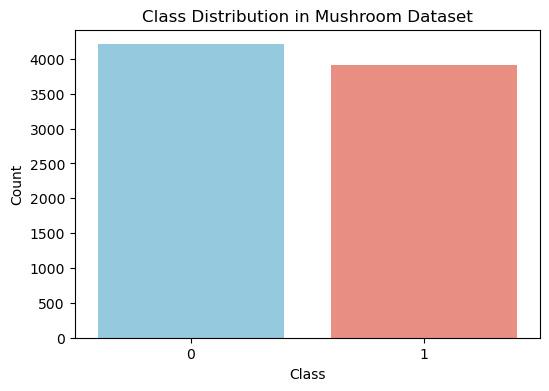

In [121]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df, hue='class', palette={0:'skyblue', 1:'salmon'}, dodge=False)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution in Mushroom Dataset')
plt.legend([],[], frameon=False)  # remove legend
plt.show()


# **Data Preprocessing**

In [20]:
# Encode Categorical Features 

le = LabelEncoder()

for col in df.columns:
    if df[col].dtypes == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [22]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


# **Model Building**

In [25]:
# Features and Target 

X = df.drop(columns=['class'])

y = df['class']

# Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# HyperParameter Tuning Using Optuna

In [61]:
#  Optuna Objective Function

def objective(trial):
    model_name = trial.suggest_categorical(
        'model', 
        ['Logistic Regression', 'Random Forest', 'Xgboost', 'SVM', 'GradientBoosting']
    )

    # Logistic Regression
    if model_name == 'Logistic Regression':
        c = trial.suggest_float('lr_C', 0.1, 100, log=True)
        solver = trial.suggest_categorical('lr_solver', ['liblinear', 'saga', 'lbfgs', 'newton-cg'])

        if solver in ['lbfgs', 'newton-cg']:
            penalty = trial.suggest_categorical('lr_penalty_lbfgs_nc', ['l2', None])  # None instead of 'none'
        elif solver == 'liblinear':
            penalty = trial.suggest_categorical('lr_penalty_liblinear', ['l1', 'l2'])
        else:  # saga
            penalty = trial.suggest_categorical('lr_penalty_saga', ['l1', 'l2', 'elasticnet', None])  # None instead of 'none'

        if penalty == 'elasticnet':
            l1_ratio = trial.suggest_float('lr_l1_ratio', 0.0, 1.0)
        else:
            l1_ratio = None

        model = LogisticRegression(
            C=c,
            penalty=penalty,
            solver=solver,
            l1_ratio=l1_ratio,
            max_iter=5000,
            random_state=42
        )

    # Random Forest
    elif model_name == 'Random Forest':
        n_estimators = trial.suggest_int('rf_n_estimators', 50, 300)
        max_depth = trial.suggest_int('rf_max_depth', 3, 20)
        min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('rf_min_samples_leaf', 1, 10)
        bootstrap = trial.suggest_categorical('rf_bootstrap', [True, False])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )

    # XGBoost
    elif model_name == 'Xgboost':
        eta = trial.suggest_float("xgb_learning_rate", 0.01, 0.3, log=True)
        max_depth = trial.suggest_int("xgb_max_depth", 2, 12)
        n_estimators = trial.suggest_int("xgb_n_estimators", 50, 500)
        subsample = trial.suggest_float("xgb_subsample", 0.5, 1.0)
        colsample_bytree = trial.suggest_float("xgb_colsample_bytree", 0.5, 1.0)
        gamma = trial.suggest_float("xgb_gamma", 0, 5)
        min_child_weight = trial.suggest_int("xgb_min_child_weight", 1, 10)
        reg_alpha = trial.suggest_float("xgb_reg_alpha", 0.0, 5.0)
        reg_lambda = trial.suggest_float("xgb_reg_lambda", 0.0, 5.0)

        model = XGBClassifier(
            learning_rate=eta,
            max_depth=max_depth,
            n_estimators=n_estimators,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            gamma=gamma,
            min_child_weight=min_child_weight,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            random_state=42,
            use_label_encoder=False,
            eval_metric="logloss"
        )

    # SVM
    elif model_name == 'SVM':
        c = trial.suggest_float('svm_C', 0.1, 100, log=True)
        kernel = trial.suggest_categorical('svm_kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_categorical('svm_gamma', ['scale', 'auto'])

        model = SVC(
            C=c,
            kernel=kernel,
            gamma=gamma,
            probability=True,
            random_state=42
        )

    # Gradient Boosting
    else:  
        n_estimators = trial.suggest_int("gb_n_estimators", 50, 500)
        learning_rate = trial.suggest_float("gb_learning_rate", 0.01, 0.3, log=True)
        max_depth = trial.suggest_int("gb_max_depth", 2, 10)
        subsample = trial.suggest_float("gb_subsample", 0.5, 1.0)
        min_samples_split = trial.suggest_int("gb_min_samples_split", 2, 20)
        min_samples_leaf = trial.suggest_int("gb_min_samples_leaf", 1, 20)

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    # Evaluate with cross-validation
    score = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy").mean()
    return score


In [63]:
# Run Optuna Study

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

[I 2025-09-13 12:41:32,505] A new study created in memory with name: no-name-7f3ef766-37d1-46ac-8005-86a287ad301d
[I 2025-09-13 12:41:32,704] Trial 0 finished with value: 0.9461448718096214 and parameters: {'model': 'Logistic Regression', 'lr_C': 0.2584896327623962, 'lr_solver': 'liblinear', 'lr_penalty_liblinear': 'l2'}. Best is trial 0 with value: 0.9461448718096214.
D:\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:41:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
D:\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:41:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
D:\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:41:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learn

In [64]:
print("\nBest Params:", study.best_params)
print("Best Accuracy:", study.best_value)


Best Params: {'model': 'GradientBoosting', 'gb_n_estimators': 319, 'gb_learning_rate': 0.23242296460923748, 'gb_max_depth': 6, 'gb_subsample': 0.5653595212925064, 'gb_min_samples_split': 7, 'gb_min_samples_leaf': 5}
Best Accuracy: 1.0


# **Model Evaluation**

In [67]:
best_params = study.best_params.copy()

In [69]:
best_params

{'model': 'GradientBoosting',
 'gb_n_estimators': 319,
 'gb_learning_rate': 0.23242296460923748,
 'gb_max_depth': 6,
 'gb_subsample': 0.5653595212925064,
 'gb_min_samples_split': 7,
 'gb_min_samples_leaf': 5}

In [105]:
# Copy best params
best_params = study.best_params.copy()

# Remove the 'model' key since it's not a valid hyperparameter
#best_params.pop('model', None)
best_model_name = best_params.pop("model")


In [75]:
# Create the best GradientBoosting model with tuned parameters
best_model = GradientBoostingClassifier(**{
    "n_estimators": best_params["gb_n_estimators"],
    "learning_rate": best_params["gb_learning_rate"],
    "max_depth": best_params["gb_max_depth"],
    "subsample": best_params["gb_subsample"],
    "min_samples_split": best_params["gb_min_samples_split"],
    "min_samples_leaf": best_params["gb_min_samples_leaf"],
    "random_state": 42
})


In [77]:
# Fit the best model on train data
best_model.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.23242296460923748
,n_estimators,319
,subsample,0.5653595212925064
,criterion,'friedman_mse'
,min_samples_split,7
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_depth,6
,min_impurity_decrease,0.0
,init,None


# **Predict on Test Data**

In [79]:
# Predictions
y_pred = best_model.predict(X_test)

In [81]:
# Accuracy score
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 1.0


# Checking Model Using ROC-AUC Curve

In [88]:
# Probabilities & ROC Curve

y_proba = best_model.predict_proba(X_test)[:, 1]  # probability for class 1


In [94]:
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9999999999999999


Best Threshold: 0.9999998100423858


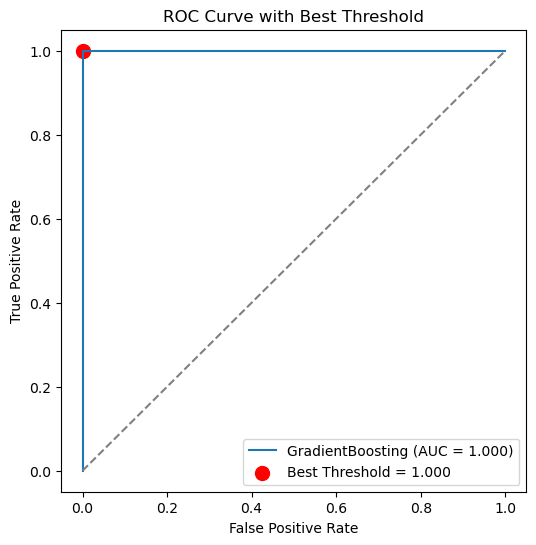

In [107]:
# Compute ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Best Threshold using Youden's J statistic
j_scores = tpr - fpr
j_best_idx = j_scores.argmax()
best_threshold = thresholds[j_best_idx]
print("Best Threshold:", best_threshold)

# ===============================
# Plot ROC curve with Best Threshold
# ===============================
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc:.3f})")
#plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Mark best threshold
plt.scatter(fpr[j_best_idx], tpr[j_best_idx], color='red', s=100, label=f"Best Threshold = {best_threshold:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Best Threshold")
plt.legend(loc="lower right")
plt.show()

In [109]:
# Predictions using Best Threshold
y_pred_best = (y_proba >= best_threshold).astype(int)

In [111]:
# Accuracy at best threshold
acc_best = accuracy_score(y_test, y_pred_best)
print("Test Accuracy (best threshold):", acc_best)

Test Accuracy (best threshold): 1.0
